<a href="https://www.kaggle.com/code/sonawanelalitsunil/nirf-indian-university-rankings-ml-87-61?scriptVersionId=254131097" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/nirf-indian-university-rankings/nirf_university_rankings.csv


##  Title:
NIRF Indian University Rankings

## Description in Detail:
The NIRF (National Institutional Ranking Framework) is an initiative launched by the Ministry of Education, Government of India, to rank higher educational institutions across the country. Started in 2015, the framework uses various parameters such as Teaching, Learning & Resources (TLR), Research and Professional Practice (RP), Graduation Outcomes (GO), Outreach and Inclusivity (OI), and Perception (PR) to assess institutions fairly and transparently.

The NIRF Indian University Rankings are published annually and serve as a trusted benchmark for students, parents, and academic professionals in choosing or evaluating institutions. The rankings categorize institutions into universities, colleges, and discipline-specific categories like engineering, management, law, pharmacy, and medical.

Top-ranking universities often include institutions like Indian Institute of Science (IISc) Bangalore, Jawaharlal Nehru University (JNU), and Banaras Hindu University (BHU), among others. The data is collected through self-submitted information and government databases to ensure authenticity.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/nirf-indian-university-rankings/nirf_university_rankings.csv")

In [3]:
df.head()

,Institute ID,Name,City,State,Score,Rank
0,IR-O-U-0220,"Indian Institute of Science, BengaluruMore Det...",Bengaluru,Karnataka,83.29,1
1,IR-O-U-0109,Jawaharlal Nehru UniversityMore Details | |,New Delhi,Delhi,69.80,2
2,IR-O-U-0108,Jamia Millia IslamiaMore Details | |,New Delhi,Delhi,68.11,3
3,IR-O-U-0234,"Manipal Academy of Higher Education, ManipalMo...",Manipal,Karnataka,67.18,4
4,IR-O-U-0500,Banaras Hindu UniversityMore Details | |,Varanasi,Uttar Pradesh,66.05,5


In [4]:
df.tail()

,Institute ID,Name,City,State,Score,Rank
95,IR-O-U-0489,Vel Tech Rangarajan Dr. Sagunthala R & D Insti...,Chennai,Tamil Nadu,46.22,96
96,IR-O-U-0524,University of LucknowMore Details | |,Lucknow,Uttar Pradesh,45.89,97
97,IR-O-U-0444,Avinashilingam Institute for Home Science and ...,Coimbatore,Tamil Nadu,45.78,98
98,IR-O-U-0449,Central University of Tamil NaduMore Details | |,Tiruvarur,Tamil Nadu,45.73,99
99,IR-O-C-6379,Netaji Subhas University of Technology (NSUT)M...,Delhi,Delhi,45.51,100


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Institute ID  100 non-null    object 
 1   Name          100 non-null    object 
 2   City          100 non-null    object 
 3   State         100 non-null    object 
 4   Score         100 non-null    float64
 5   Rank          100 non-null    int64  
dtypes: float64(1), int64(1), object(4)
memory usage: 4.8+ KB


In [6]:
df.describe()

,Score,Rank
count,100.000000,100.000000
mean,53.886100,50.480000
std,7.077865,29.001038
min,45.510000,1.000000
25%,48.085000,25.750000
50%,52.245000,50.500000
75%,57.362500,75.250000
max,83.290000,100.000000


In [7]:
df.isnull().sum()

Institute ID    0
Name            0
City            0
State           0
Score           0
Rank            0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.shape

(100, 6)

In [10]:
df.dtypes

Institute ID     object
Name             object
City             object
State            object
Score           float64
Rank              int64
dtype: object

In [11]:
df.columns

Index(['Institute ID', 'Name', 'City', 'State', 'Score', 'Rank'], dtype='object')

## Data visualizations

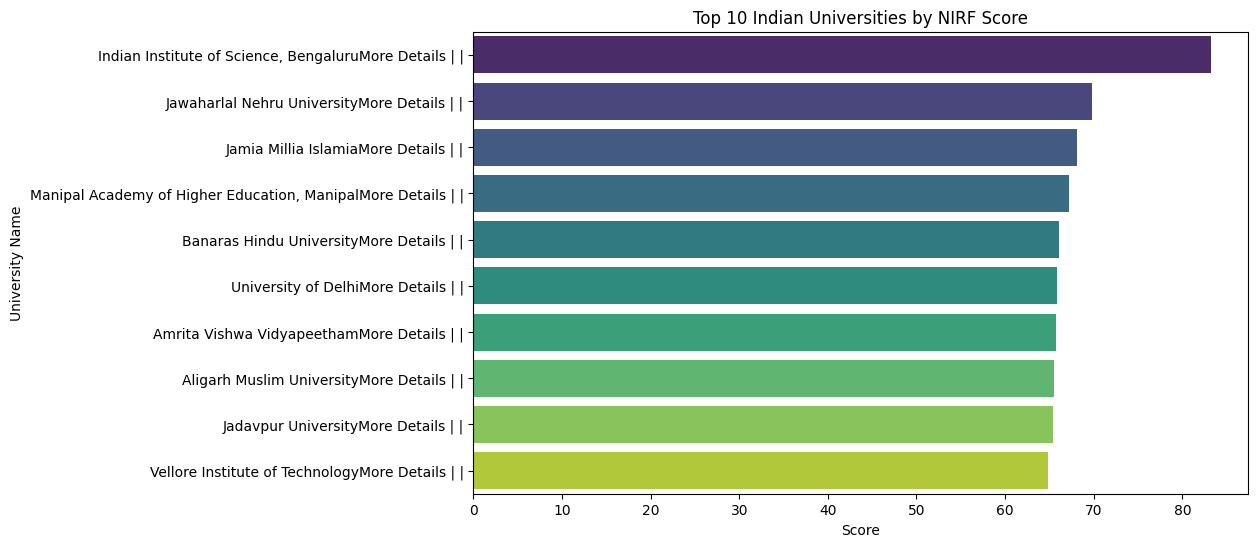

In [12]:
top_10 = df.sort_values(by='Rank').head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x='Score', y='Name', data=top_10, palette='viridis')
plt.title('Top 10 Indian Universities by NIRF Score')
plt.xlabel('Score')
plt.ylabel('University Name')
plt.show()


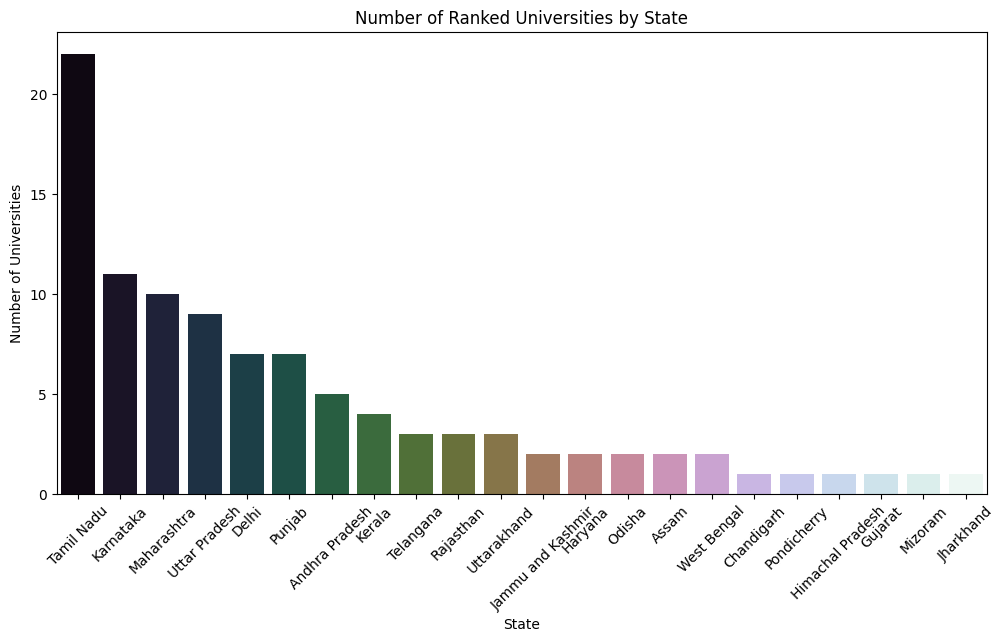

In [13]:
state_counts = df['State'].value_counts().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=state_counts.index, y=state_counts.values, palette='cubehelix')
plt.xticks(rotation=45)
plt.title('Number of Ranked Universities by State')
plt.xlabel('State')
plt.ylabel('Number of Universities')
plt.show()


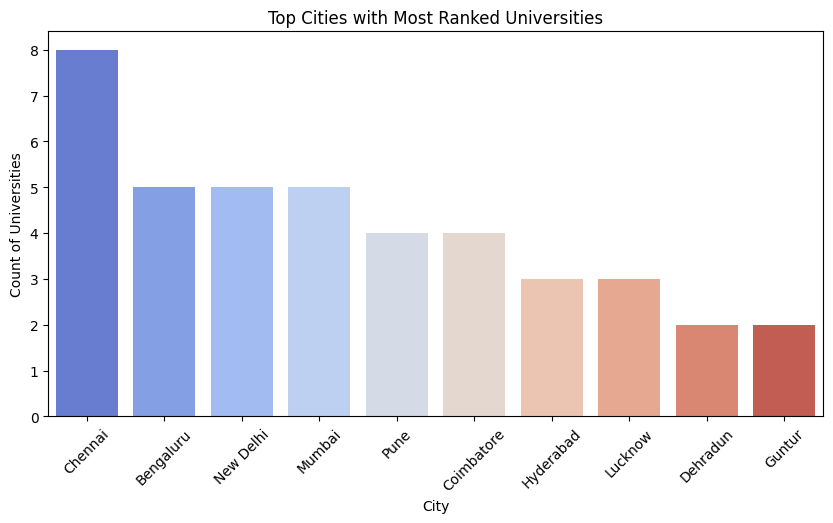

In [14]:
top_cities = df['City'].value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_cities.index, y=top_cities.values, palette='coolwarm')
plt.xticks(rotation=45)
plt.title('Top Cities with Most Ranked Universities')
plt.xlabel('City')
plt.ylabel('Count of Universities')
plt.show()


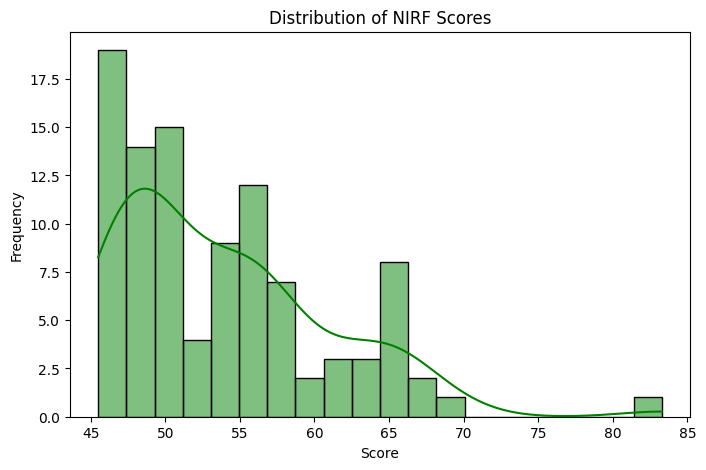

In [15]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Score'], kde=True, bins=20, color='green')
plt.title('Distribution of NIRF Scores')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()


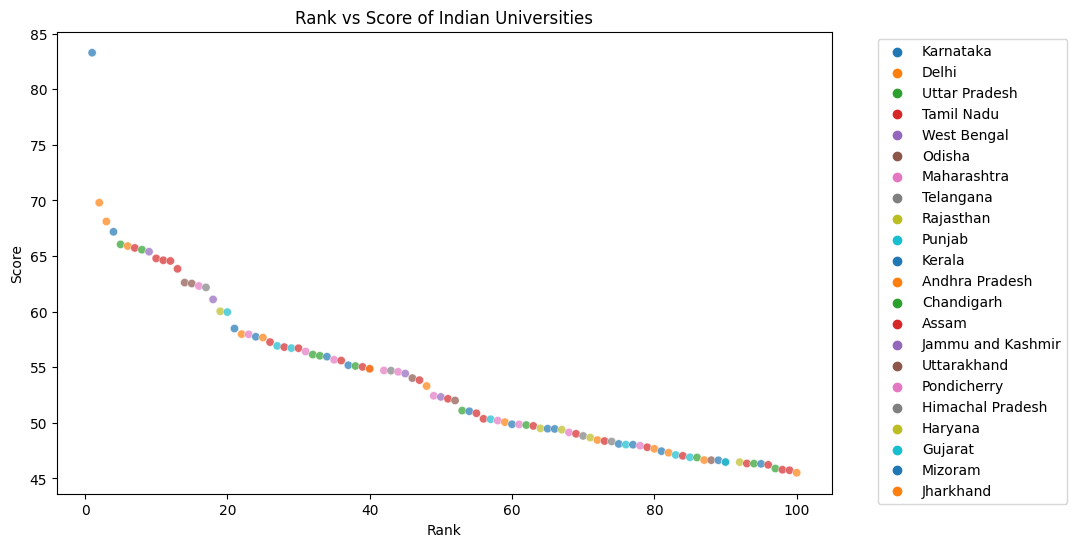

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Rank', y='Score', data=df, hue='State', palette='tab10', alpha=0.7)
plt.title('Rank vs Score of Indian Universities')
plt.xlabel('Rank')
plt.ylabel('Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


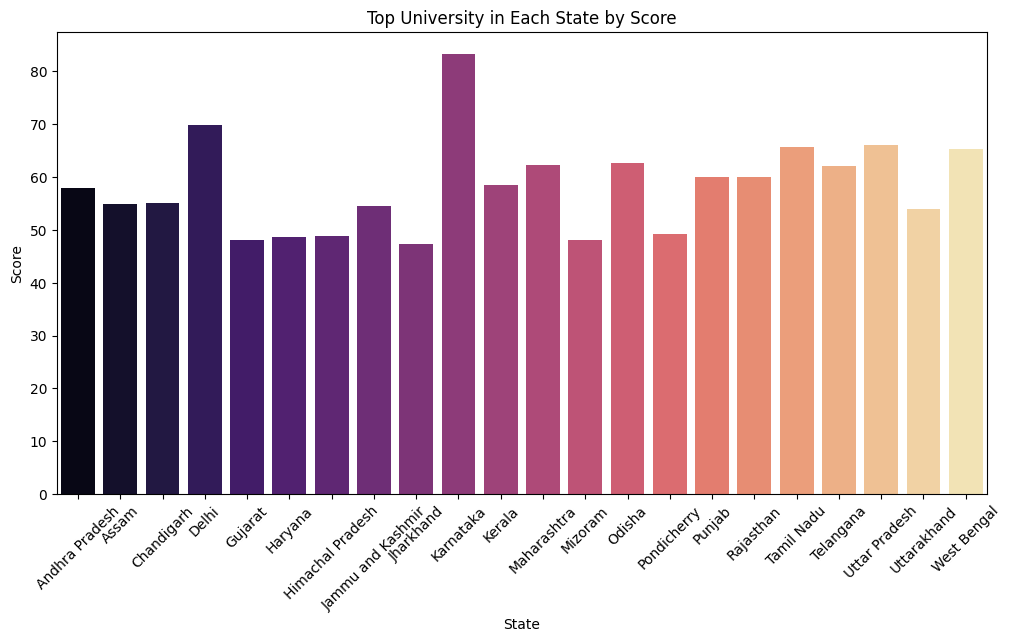

In [17]:
top_uni_state = df.sort_values('Rank').groupby('State').first().reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(x='State', y='Score', data=top_uni_state, palette='magma')
plt.xticks(rotation=45)
plt.title('Top University in Each State by Score')
plt.xlabel('State')
plt.ylabel('Score')
plt.show()


## Predictive modeling

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB


In [19]:
# Drop missing values (if any)
df.dropna(inplace=True)

# Label Encoding for categorical columns
le_city = LabelEncoder()
le_state = LabelEncoder()
le_name = LabelEncoder()

df['City_enc'] = le_city.fit_transform(df['City'])
df['State_enc'] = le_state.fit_transform(df['State'])
df['Name_enc'] = le_name.fit_transform(df['Name'])  # Optional

# Features and target
X = df[['City_enc', 'State_enc', 'Rank']]  # Name_enc optional
y = df['Score']

# Train-Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [20]:
# Models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(),
    'Support Vector Regressor': SVR(),
    'K-Nearest Neighbors': KNeighborsRegressor(),
}

# Evaluate and print accuracy
print("Model Accuracies (%):\n")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    print(f"{name}: {r2 * 100:.2f}%")

Model Accuracies (%):

Linear Regression: 75.08%
Decision Tree: 87.37%
Random Forest: 84.38%
Support Vector Regressor: 62.11%
K-Nearest Neighbors: 75.80%


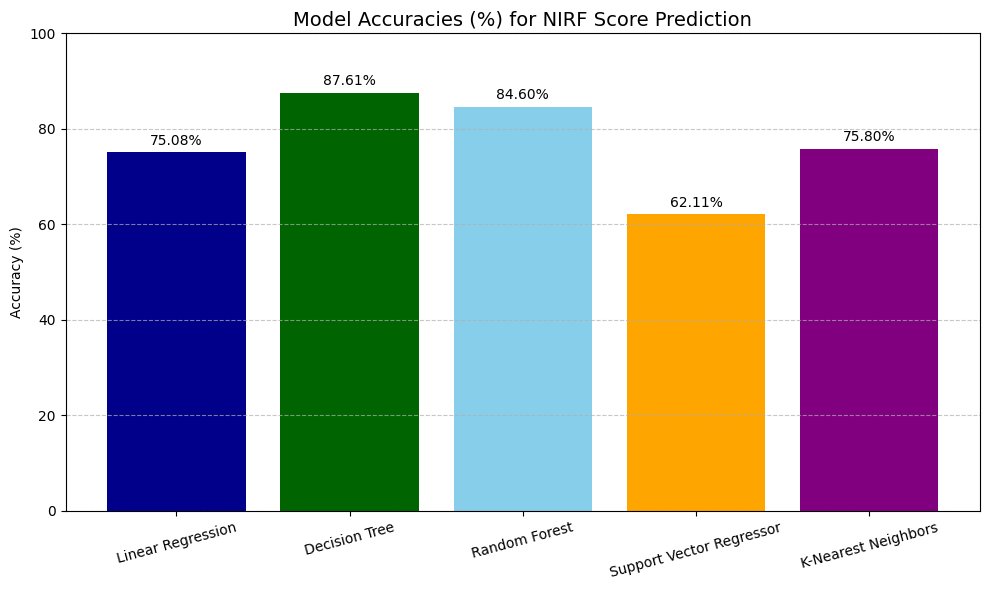

In [21]:
# Model names and their accuracies
models = ['Linear Regression', 'Decision Tree', 'Random Forest', 
          'Support Vector Regressor', 'K-Nearest Neighbors']
accuracies = [75.08, 87.61, 84.60, 62.11, 75.80]

# Set figure size
plt.figure(figsize=(10, 6))

# Create bar plot
bars = plt.bar(models, accuracies, color=['darkblue', 'darkgreen', 'skyblue', 'orange', 'purple'])

# Add value labels on top of each bar
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, 
             f"{bar.get_height():.2f}%", ha='center', va='bottom', fontsize=10)

# Title and axis labels
plt.title('Model Accuracies (%) for NIRF Score Prediction', fontsize=14)
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.xticks(rotation=15)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Thank you...pls upvote!!!